In [1]:
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('../data/processed/Merged_dataset.csv')

## 1. Product Categories with Top sales

In [3]:
product_category_count=(
    df
    .groupby('product_category_name') 
    .agg(
        top_selling_category=("product_category_name",'count')
    )
)

product_category_count.reset_index().sort_values(by='top_selling_category', ascending=False).head(5)

,product_category_name,top_selling_category
13,cama_mesa_banho,10832
11,beleza_saude,9292
32,esporte_lazer,8141
54,moveis_decoracao,7143
44,informatica_acessorios,7133


In [4]:
#total product sell
total_prod_sum=product_category_count['top_selling_category'].sum()

In [5]:
# total sum of top 5 products
top_5_prod_sum=product_category_count['top_selling_category'].sort_values(ascending=False).head().sum()
print('Sum of total sales of top 5 products',top_5_prod_sum)

Sum of total sales of top 5 products 42541


In [6]:
# percentage of top 5 products 
print('Percentage of total sales of top 5 products', (top_5_prod_sum/total_prod_sum)*100)

Percentage of total sales of top 5 products 40.40594962197485


## 2. Product Demand Analysis

In [7]:
df['order_purchase_timestamp']=pd.to_datetime(df['order_purchase_timestamp'])
df['purchase_year']=df['order_purchase_timestamp'].dt.year
df['purchase_month']=df['order_purchase_timestamp'].dt.month

In [8]:
df=(
    df 
    .groupby(['purchase_year','purchase_month'])['product_category_name']
    .value_counts()
    .reset_index()
)
df.head(2)

,purchase_year,purchase_month,product_category_name,count
0,2016,9,moveis_decoracao,2
1,2016,9,telefonia,1


In [9]:
def prod_selling_stats(prod_category): 
    years = [2016, 2017, 2018] 
    plot_color=['r','g','b']
    fig, ax = plt.subplots(3, 1, figsize=(10, 5))
    fig.suptitle('Product History Year')

    for idx, year in enumerate(years): 
        curr_year_data = df[
            (df['purchase_year'] == year) &
            (df['product_category_name'] == prod_category)
        ] # this dataframe contains only rows of the selected year and prod category
        curr_year_data = curr_year_data.sort_values('purchase_month')

        months = curr_year_data['purchase_month'].to_numpy()
        counts = curr_year_data['count'].to_numpy()

        ax[idx].plot(months, counts, marker='o',c=plot_color[idx], label=str(year))
        ax[idx].set_xlabel('Months')
        ax[idx].set_ylabel('Total Units Sold')
        ax[idx].set_title(f'{prod_category} history for {year}')
        ax[idx].legend()

    plt.tight_layout()
    plt.show()


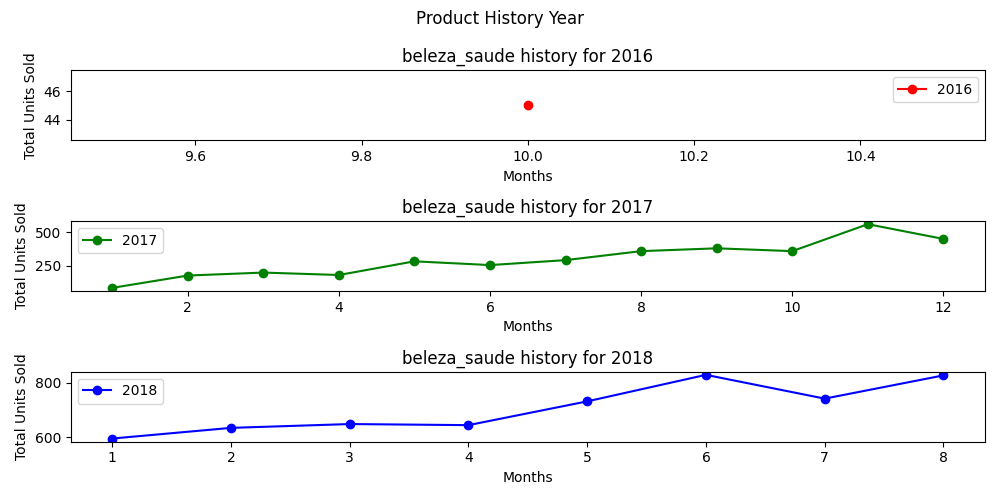

In [10]:
prod_selling_stats('beleza_saude')

In [13]:
result = (
    df
    .groupby(['purchase_year',
              'product_category_name',
              'purchase_month'])
    .size()
    .unstack(fill_value=0) # without this purchase month would be a column 
    .reset_index()
)

In [15]:
result.head(10)

purchase_month,purchase_year,product_category_name,1,2,3,4,5,6,7,8,9,10,11,12
0,2016,alimentos,0,0,0,0,0,0,0,0,0,1,0,0
1,2016,audio,0,0,0,0,0,0,0,0,0,1,0,0
2,2016,automotivo,0,0,0,0,0,0,0,0,0,1,0,0
3,2016,bebes,0,0,0,0,0,0,0,0,0,1,0,0
4,2016,beleza_saude,0,0,0,0,0,0,0,0,0,1,0,0
5,2016,brinquedos,0,0,0,0,0,0,0,0,0,1,0,0
6,2016,cama_mesa_banho,0,0,0,0,0,0,0,0,0,1,0,0
7,2016,climatizacao,0,0,0,0,0,0,0,0,0,1,0,0
8,2016,consoles_games,0,0,0,0,0,0,0,0,0,1,0,0
9,2016,cool_stuff,0,0,0,0,0,0,0,0,0,1,0,0
